# ⚡ Conversão Analógico-Digital (ADC)

## Objetivos de Aprendizagem

Ao final deste notebook, você será capaz de:

1. **Descrever** o que é um sinal analógico e por que precisamos convertê-lo para digital
2. **Aplicar** o conceito de amostragem e calcular a frequência de amostragem necessária
3. **Enunciar** o Teorema de Nyquist-Shannon e identificar quando ocorre *aliasing*
4. **Calcular** a resolução de um ADC em bits, o passo de quantização (Δ) e o SQNR
5. **Implementar** um pipeline ADC completo em Python
6. **Experimentar** livremente variando parâmetros e observando os efeitos

---

## Pré-requisitos

- Funções trigonométricas (seno, cosseno)
- Conceito de frequência e período
- Noções básicas de Python e NumPy

---

> **Como usar este notebook:** Execute as células em ordem (Shift+Enter). Nas seções marcadas com 🔧, você pode alterar os parâmetros e re-executar para ver os efeitos.

In [1]:
# Instalação das dependências — execute esta célula apenas uma vez
# %pip instala no kernel ativo (correto para VS Code e Jupyter Lab)
%pip install numpy matplotlib scipy

print('\n✅ Instalação concluída! Execute a próxima célula para importar as bibliotecas.')

Note: you may need to restart the kernel to use updated packages.

✅ Instalação concluída! Execute a próxima célula para importar as bibliotecas.


In [2]:
# Importações necessárias — apenas bibliotecas padrão da ciência de dados
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# Configurações globais de estilo para todos os gráficos
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8fafc',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'font.size': 11,
})

# Paleta de cores consistente em todo o notebook
COR_ORIGINAL  = '#2563EB'  # azul   — sinal analógico original
COR_AMOSTRADO = '#F59E0B'  # laranja — amostras
COR_QUANT     = '#10B981'  # verde   — sinal quantizado
COR_ERRO      = '#EF4444'  # vermelho — erro de quantização

print('✅ Bibliotecas importadas com sucesso!')

✅ Bibliotecas importadas com sucesso!


---
## Seção 1 — Sinal Analógico de Referência

### O que é um sinal analógico?

Um **sinal analógico** é uma grandeza física que varia de forma **contínua** no tempo e pode assumir **infinitos valores** dentro de uma faixa. Exemplos do cotidiano:

| Sensor | Grandeza física | Sinal elétrico |
|--------|----------------|----------------|
| Microfone | Pressão sonora | Tensão (mV) |
| Termômetro | Temperatura | Corrente (mA) |
| Acelerômetro | Aceleração | Tensão (mV) |
| ECG | Campo elétrico cardíaco | Tensão (µV–mV) |

Matematicamente, representamos um sinal senoidal simples como:

$$x(t) = A \cdot \sin(2\pi f \cdot t) + \eta(t)$$

Onde $A$ é a amplitude, $f$ é a frequência em Hz, e $\eta(t)$ é ruído aditivo (presente em qualquer sistema real).

> **Analogia:** Imagine uma onda no oceano — ela sobe e desce suavemente, sem "saltos". Isso é um sinal analógico.

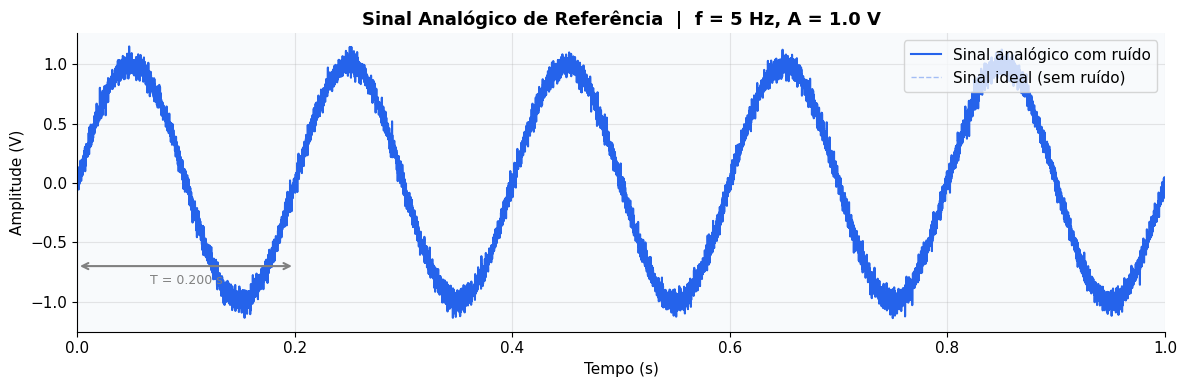

Período do sinal: T = 1/f = 1/5 = 0.2000 s
Amplitude: 1.0 V  |  Ruído (σ): 0.05 V  |  SNR: 26.0 dB


In [3]:
# ──────────────────────────────────────────
# 🔧 PARÂMETROS DO SINAL (edite aqui)
# ──────────────────────────────────────────
signal_freq = 5      # Hz — frequência fundamental do sinal
amplitude   = 1.0    # Volts — amplitude de pico
noise_std   = 0.05   # desvio-padrão do ruído gaussiano aditivo
t_total     = 1.0    # segundos — duração do sinal
# ──────────────────────────────────────────

np.random.seed(42)  # garante reprodutibilidade dos resultados aleatórios

# Alta resolução temporal simula o sinal "contínuo"
# 10000 pontos em 1 segundo → passo de 0,1 ms (imperceptível ao olho)
N_continuo = 10_000
t_cont = np.linspace(0, t_total, N_continuo, endpoint=False)

# Geração do sinal: senoidal + ruído gaussiano branco
sinal_puro  = amplitude * np.sin(2 * np.pi * signal_freq * t_cont)
ruido       = np.random.normal(0, noise_std, size=N_continuo)
sinal_cont  = sinal_puro + ruido  # sinal "real" com ruído

# ──── Visualização ────
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(t_cont, sinal_cont, color=COR_ORIGINAL, lw=1.5, label='Sinal analógico com ruído')
ax.plot(t_cont, sinal_puro, color=COR_ORIGINAL, lw=1, ls='--', alpha=0.4, label='Sinal ideal (sem ruído)')

ax.set_title(f'Sinal Analógico de Referência  |  f = {signal_freq} Hz, A = {amplitude} V', fontsize=13, fontweight='bold')
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Amplitude (V)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, t_total)

# Anotação do período
T_sinal = 1 / signal_freq
ax.annotate('', xy=(T_sinal, -amplitude*0.7), xytext=(0, -amplitude*0.7),
            arrowprops=dict(arrowstyle='<->', color='gray', lw=1.5))
ax.text(T_sinal/2, -amplitude*0.85, f'T = {T_sinal:.3f} s', ha='center', color='gray', fontsize=9)

plt.tight_layout()
plt.show()

print(f'Período do sinal: T = 1/f = 1/{signal_freq} = {T_sinal:.4f} s')
print(f'Amplitude: {amplitude} V  |  Ruído (σ): {noise_std} V  |  SNR: {20*np.log10(amplitude/noise_std):.1f} dB')

---
## Seção 2 — Amostragem

### O que é amostragem?

**Amostragem** é o processo de capturar o valor do sinal analógico em instantes **discretos** de tempo, separados por um intervalo fixo chamado **período de amostragem** $T_s$.

$$T_s = \frac{1}{f_s}$$

Onde $f_s$ é a **frequência de amostragem** (em Hz ou amostras/segundo).

> **Analogia dos fotogramas:** Um filme de cinema captura 24 "fotografias" do mundo real por segundo ($f_s = 24$ Hz). O movimento parece contínuo porque nosso cérebro "preenche" os intervalos. A amostragem de sinais funciona de forma similar — capturamos "instantâneos" do sinal em momentos regulares.

O processo matemático é:

$$x[n] = x(n \cdot T_s) = x\left(\frac{n}{f_s}\right), \quad n = 0, 1, 2, \ldots$$

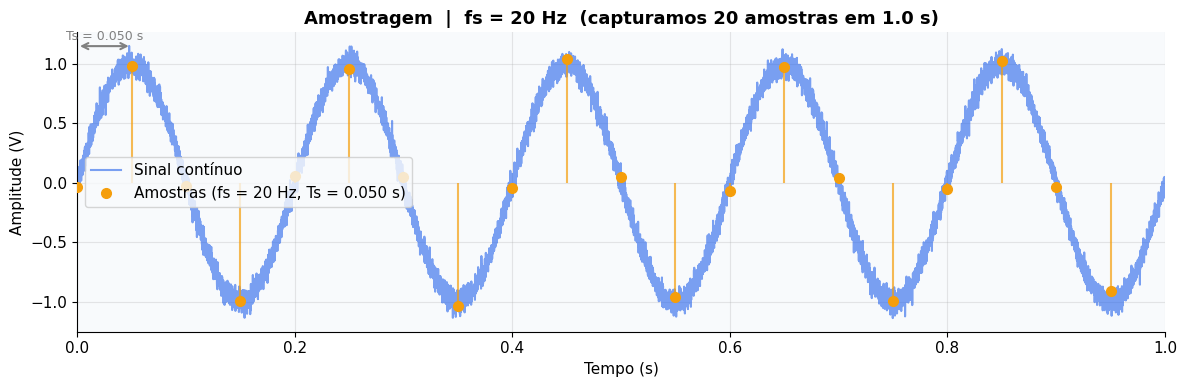

Total de amostras: 20
Período de amostragem: Ts = 1/fs = 1/20 = 0.0500 s


In [4]:
# ──────────────────────────────────────────
# 🔧 PARÂMETRO DE AMOSTRAGEM (edite aqui)
# ──────────────────────────────────────────
fs = 20  # Hz — frequência de amostragem
# ──────────────────────────────────────────

Ts = 1 / fs  # período de amostragem

# Instantes de amostragem: múltiplos de Ts dentro do intervalo [0, t_total)
t_amostras = np.arange(0, t_total, Ts)

# Captura os valores do sinal CONTÍNUO nos instantes de amostragem
# (na prática, é o que o circuito Sample & Hold faz)
x_amostrado = amplitude * np.sin(2 * np.pi * signal_freq * t_amostras) + \
              np.random.normal(0, noise_std, size=len(t_amostras))

# ──── Visualização ────
fig, ax = plt.subplots(figsize=(12, 4))

# Sinal contínuo de fundo
ax.plot(t_cont, sinal_cont, color=COR_ORIGINAL, lw=1.5, alpha=0.6, label='Sinal contínuo')

# Amostras como "lollipops" (hastes + pontos)
ax.vlines(t_amostras, 0, x_amostrado, color=COR_AMOSTRADO, lw=1.5, alpha=0.7)
ax.plot(t_amostras, x_amostrado, 'o', color=COR_AMOSTRADO, ms=7,
        label=f'Amostras (fs = {fs} Hz, Ts = {Ts:.3f} s)', zorder=5)

# Destaque visual do intervalo Ts entre as duas primeiras amostras
if len(t_amostras) >= 2:
    y_seta = amplitude * 1.15
    ax.annotate('', xy=(t_amostras[1], y_seta), xytext=(t_amostras[0], y_seta),
                arrowprops=dict(arrowstyle='<->', color='gray', lw=1.5))
    ax.text((t_amostras[0] + t_amostras[1]) / 2, y_seta + 0.05,
            f'Ts = {Ts:.3f} s', ha='center', fontsize=9, color='gray')

ax.set_title(f'Amostragem  |  fs = {fs} Hz  (capturamos {len(t_amostras)} amostras em {t_total} s)', fontsize=13, fontweight='bold')
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Amplitude (V)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, t_total)

plt.tight_layout()
plt.show()

print(f'Total de amostras: {len(t_amostras)}')
print(f'Período de amostragem: Ts = 1/fs = 1/{fs} = {Ts:.4f} s')

### 📝 Exercício Proposto

> **Experimento:** Volte na célula acima e altere `fs = 8` Hz. O que acontece com as amostras? Elas ainda representam bem o sinal original de 5 Hz?
>
> **Dica:** Com `fs = 8` Hz e `signal_freq = 5` Hz, temos $f_s < 2 \cdot f_{sinal}$. Isso viola uma condição importante que veremos a seguir...

---
## Seção 3 — Teorema de Nyquist-Shannon

### Enunciado

> **Teorema de Nyquist-Shannon:** Para reconstruir perfeitamente um sinal de banda limitada com frequência máxima $f_{max}$, a frequência de amostragem deve satisfazer:
>
> $$f_s \geq 2 \cdot f_{max}$$

A frequência $f_N = f_s / 2$ é chamada de **frequência de Nyquist** (ou frequência de dobramento). Qualquer componente de frequência acima de $f_N$ no sinal original causará **aliasing**.

### O que é Aliasing?

**Aliasing** (em português: *sobreposição espectral* ou *confusão de frequências*) ocorre quando amostras insuficientes fazem com que uma frequência alta seja "confundida" com uma frequência mais baixa.

> **Analogia:** Pense nas rodas de um carro em um vídeo: às vezes elas parecem girar ao contrário! Isso é aliasing — a câmera não captura quadros rápido o suficiente para representar corretamente a rotação real.

A frequência "fantasma" gerada pelo aliasing é:

$$f_{alias} = |f_{sinal} - k \cdot f_s|, \quad k \in \mathbb{Z}$$

════════════════════════════════════════════════════════════
CENÁRIO 1: fs = 50 Hz, f_sinal = 5 Hz
════════════════════════════════════════════════════════════


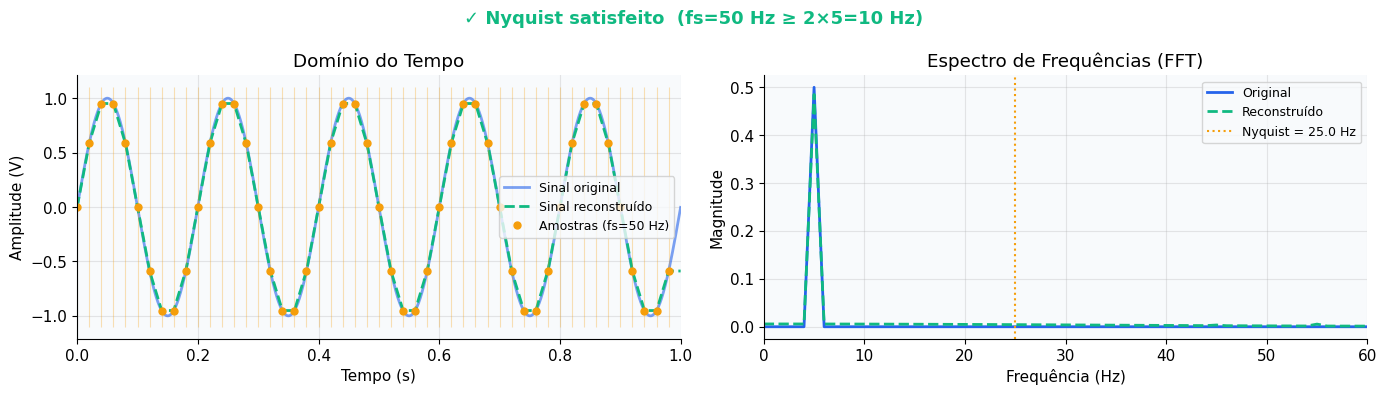

════════════════════════════════════════════════════════════
CENÁRIO 2: fs = 12 Hz, f_sinal = 5 Hz  (limite)
════════════════════════════════════════════════════════════


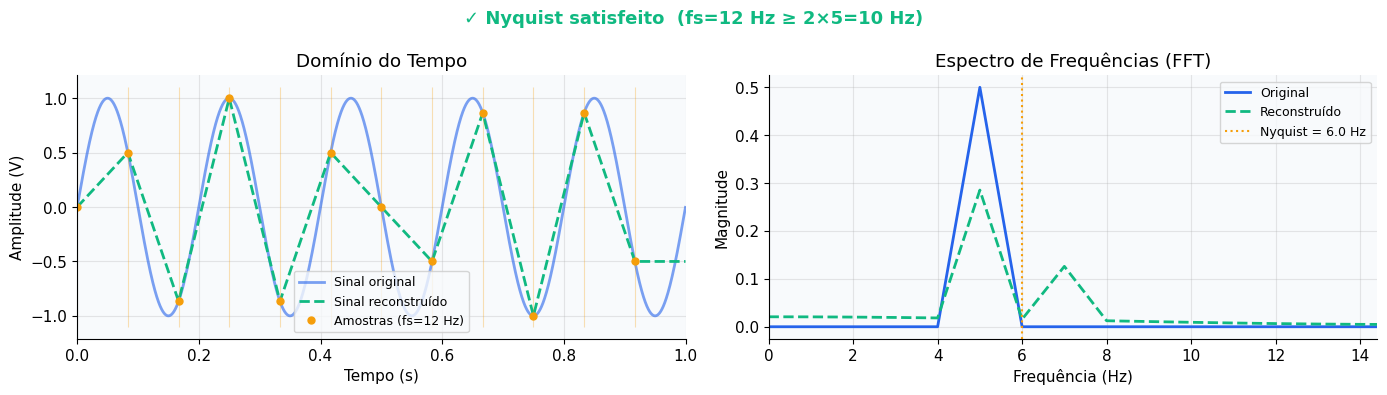

════════════════════════════════════════════════════════════
CENÁRIO 3: fs = 8 Hz, f_sinal = 5 Hz  (ALIASING!)
════════════════════════════════════════════════════════════


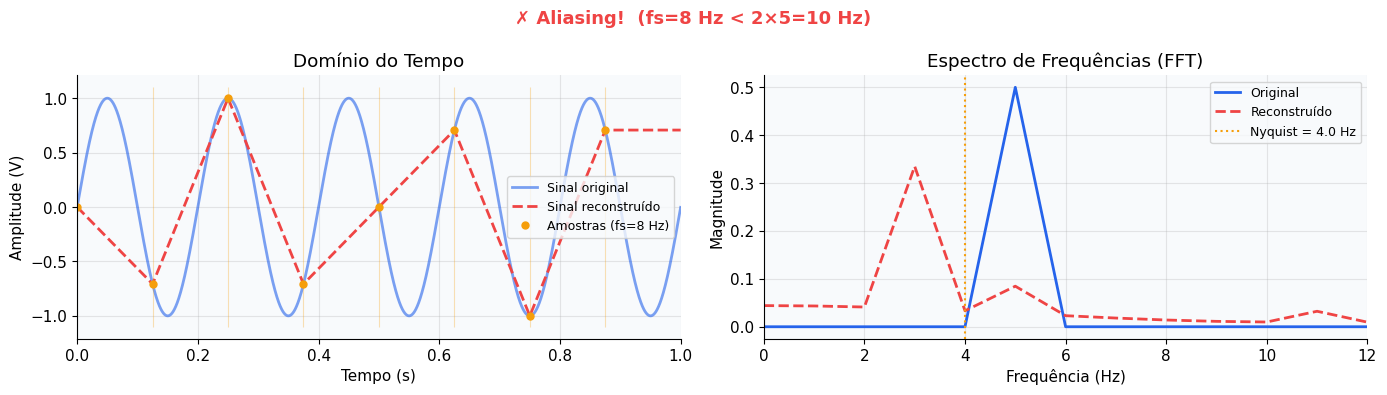

In [5]:
def demonstrar_aliasing(fs_teste, f_sinal, amplitude=1.0, t_total=1.0, noise_std=0.0):
    """
    Demonstra visualmente o aliasing comparando sinal original e reconstruído.
    Destaca em vermelho quando Nyquist é violado.
    """
    nyquist_ok = fs_teste >= 2 * f_sinal  # condição de Nyquist
    cor_status = '#10B981' if nyquist_ok else '#EF4444'
    texto_status = f'✓ Nyquist satisfeito  (fs={fs_teste} Hz ≥ 2×{f_sinal}={2*f_sinal} Hz)' \
                   if nyquist_ok else \
                   f'✗ Aliasing!  (fs={fs_teste} Hz < 2×{f_sinal}={2*f_sinal} Hz)'

    # Sinal contínuo de referência ("ground truth")
    t_cont_loc = np.linspace(0, t_total, 10_000, endpoint=False)
    sinal_ref = amplitude * np.sin(2 * np.pi * f_sinal * t_cont_loc)

    # Amostras na frequência testada
    t_am = np.arange(0, t_total, 1/fs_teste)
    x_am = amplitude * np.sin(2 * np.pi * f_sinal * t_am)

    # "Reconstrução" simples: interpola linearmente entre amostras
    # (representa o que um sistema digital veria com apenas essas amostras)
    sinal_rec = np.interp(t_cont_loc, t_am, x_am)

    # ── Painel 1: domínio do tempo ──
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(texto_status, fontsize=13, fontweight='bold', color=cor_status)

    ax = axes[0]
    ax.plot(t_cont_loc, sinal_ref, color=COR_ORIGINAL, lw=2, label='Sinal original', alpha=0.6)
    ax.plot(t_cont_loc, sinal_rec, color=cor_status, lw=2, ls='--', label='Sinal reconstruído')
    ax.vlines(t_am, -amplitude*1.1, amplitude*1.1, color=COR_AMOSTRADO, alpha=0.3, lw=0.8)
    ax.plot(t_am, x_am, 'o', color=COR_AMOSTRADO, ms=5, label=f'Amostras (fs={fs_teste} Hz)')
    ax.set_title('Domínio do Tempo')
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('Amplitude (V)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, t_total)

    # ── Painel 2: espectro de frequências (FFT) ──
    ax2 = axes[1]
    N = len(t_cont_loc)
    freqs = fftfreq(N, d=t_cont_loc[1]-t_cont_loc[0])
    idx_pos = freqs >= 0  # apenas frequências positivas

    espectro_orig = np.abs(fft(sinal_ref)) / N
    espectro_rec  = np.abs(fft(sinal_rec)) / N

    ax2.plot(freqs[idx_pos], espectro_orig[idx_pos], color=COR_ORIGINAL, lw=2, label='Original')
    ax2.plot(freqs[idx_pos], espectro_rec[idx_pos],  color=cor_status,   lw=2, ls='--', label='Reconstruído')
    ax2.axvline(fs_teste/2, color=COR_AMOSTRADO, lw=1.5, ls=':', label=f'Nyquist = {fs_teste/2} Hz')
    ax2.set_title('Espectro de Frequências (FFT)')
    ax2.set_xlabel('Frequência (Hz)')
    ax2.set_ylabel('Magnitude')
    ax2.set_xlim(0, max(fs_teste, 2*f_sinal) * 1.2)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# ── Cenário 1: fs = 50 Hz (Nyquist amplamente satisfeito) ──
print('═' * 60)
print('CENÁRIO 1: fs = 50 Hz, f_sinal = 5 Hz')
print('═' * 60)
demonstrar_aliasing(fs_teste=50, f_sinal=5)

# ── Cenário 2: fs = 12 Hz (no limite — fs = 2.4 × f_sinal) ──
print('═' * 60)
print('CENÁRIO 2: fs = 12 Hz, f_sinal = 5 Hz  (limite)')
print('═' * 60)
demonstrar_aliasing(fs_teste=12, f_sinal=5)

# ── Cenário 3: fs = 8 Hz (aliasing — fs < 2 × f_sinal) ──
print('═' * 60)
print('CENÁRIO 3: fs = 8 Hz, f_sinal = 5 Hz  (ALIASING!)')
print('═' * 60)
demonstrar_aliasing(fs_teste=8, f_sinal=5)

---
## Seção 4 — Quantização

### O que é quantização?

Após a amostragem, temos valores contínuos capturados em instantes discretos. A **quantização** converte cada valor amostrado em um número inteiro de um conjunto finito de **níveis de quantização**.

Um ADC com **N bits** pode representar $2^N$ níveis distintos. O **passo de quantização** (ou LSB — *Least Significant Bit*, Bit Menos Significativo) é:

$$\Delta = \frac{V_{range}}{2^N - 1} = \frac{V_{max} - V_{min}}{2^N - 1}$$

### Tabela comparativa

Para uma faixa de ±5 V ($V_{range}$ = 10 V):

| N (bits) | Níveis ($2^N$) | Δ (mV) | Uso típico |
|----------|---------------|---------|------------|
| 4 | 16 | 666,7 | Controle grosseiro |
| 8 | 256 | 39,2 | Áudio de baixa qualidade |
| 12 | 4.096 | 2,44 | Sensores industriais |
| 16 | 65.536 | 0,153 | Áudio CD (44,1 kHz) |
| 24 | 16.777.216 | 0,000596 | Áudio profissional |

> **Analogia:** Pense em medir a temperatura com uma régua: uma régua com marcas a cada 10°C (N=1 bit, 2 níveis) é muito imprecisa; uma com marcas a cada 0,1°C (N~7 bits) é muito melhor.

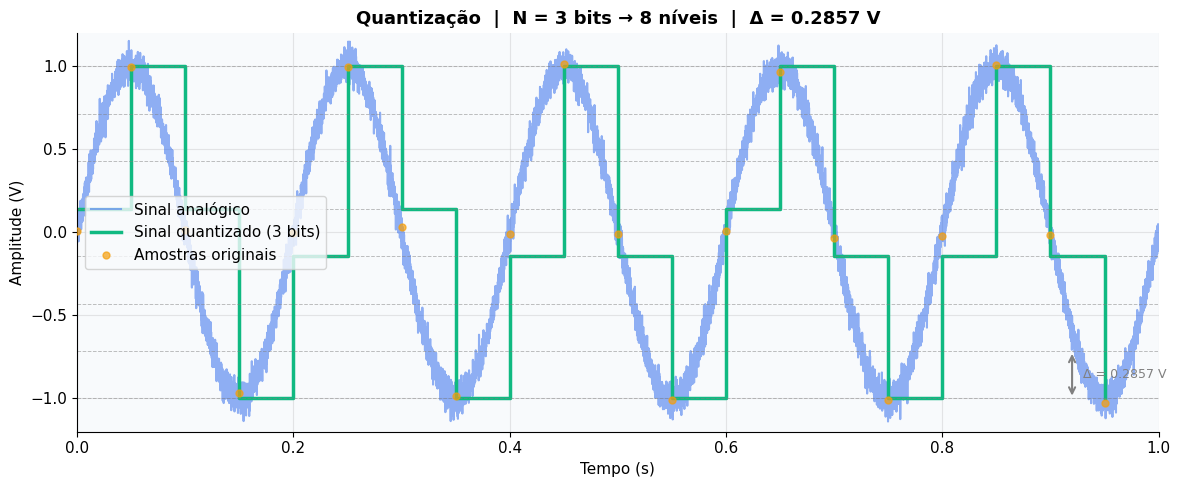

N = 3 bits → 8 níveis de quantização
Passo de quantização: Δ = 0.285714 V
Erro máximo teórico: ±Δ/2 = ±0.142857 V


In [15]:
# ──────────────────────────────────────────
# 🔧 PARÂMETROS DO QUANTIZADOR (edite aqui)
# ──────────────────────────────────────────
n_bits = 3    # número de bits do ADC
v_min  = -1.0 # tensão mínima da faixa do ADC (V)
v_max  =  1.0 # tensão máxima da faixa do ADC (V)
# ──────────────────────────────────────────

def quantizar(sinal, n_bits, v_min, v_max):
    """Quantiza um sinal para n_bits bits na faixa [v_min, v_max]."""
    n_niveis = 2 ** n_bits              # número total de níveis
    delta = (v_max - v_min) / (n_niveis - 1)  # passo entre níveis

    # Limita (clipa) o sinal à faixa do ADC para evitar saturação
    sinal_clip = np.clip(sinal, v_min, v_max)

    # Converte tensão para índice de nível (arredonda para o mais próximo)
    indices = np.round((sinal_clip - v_min) / delta).astype(int)

    # Converte índice de volta para tensão quantizada
    sinal_q = v_min + indices * delta
    return sinal_q, delta, n_niveis

# Aplica quantização ao sinal amostrado (usando fs=20 Hz da seção 2)
fs_quant = 20
t_q = np.arange(0, t_total, 1/fs_quant)
np.random.seed(42)
x_q_in = amplitude * np.sin(2 * np.pi * signal_freq * t_q) + \
          np.random.normal(0, noise_std, size=len(t_q))

x_quantizado, delta, n_niveis = quantizar(x_q_in, n_bits, v_min, v_max)

# Calcula os níveis de quantização para plotar as linhas guia
niveis = np.linspace(v_min, v_max, n_niveis)

# ──── Visualização ────
fig, ax = plt.subplots(figsize=(12, 5))

# Sinal contínuo de fundo
ax.plot(t_cont, sinal_cont, color=COR_ORIGINAL, lw=1.5, alpha=0.5, label='Sinal analógico')

# Sinal quantizado como degraus (step plot)
ax.step(t_q, x_quantizado, where='post', color=COR_QUANT, lw=2.5, label=f'Sinal quantizado ({n_bits} bits)')

# Amostras originais
ax.plot(t_q, x_q_in, 'o', color=COR_AMOSTRADO, ms=5, alpha=0.7, label='Amostras originais', zorder=5)

# Linhas tracejadas para cada nível de quantização
for nivel in niveis:
    ax.axhline(nivel, color='gray', ls='--', lw=0.7, alpha=0.5)

# Anotação do valor de Δ
ax.annotate('', xy=(t_total*0.92, niveis[1]), xytext=(t_total*0.92, niveis[0]),
            arrowprops=dict(arrowstyle='<->', color='gray', lw=1.5))
ax.text(t_total*0.93, (niveis[0]+niveis[1])/2, f'Δ = {delta:.4f} V', va='center', fontsize=9, color='gray')

ax.set_title(f'Quantização  |  N = {n_bits} bits → {n_niveis} níveis  |  Δ = {delta:.4f} V', fontsize=13, fontweight='bold')
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Amplitude (V)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, t_total)
ax.set_ylim(v_min - 0.2, v_max + 0.2)

plt.tight_layout()
plt.show()

print(f'N = {n_bits} bits → {n_niveis} níveis de quantização')
print(f'Passo de quantização: Δ = {delta:.6f} V')
print(f'Erro máximo teórico: ±Δ/2 = ±{delta/2:.6f} V')

---
## Seção 5 — Erro de Quantização e Incertezas

### Definição do erro

O **erro de quantização** é a diferença entre o valor quantizado e o valor real amostrado:

$$e[n] = x_q[n] - x[n]$$

Para um quantizador uniforme, o erro é limitado por:

$$-\frac{\Delta}{2} \leq e[n] \leq +\frac{\Delta}{2}$$

### Relação Sinal-Ruído de Quantização (SQNR)

O SQNR (*Signal-to-Quantization-Noise Ratio*) mede a qualidade da quantização. Para um sinal senoidal com N bits:

$$\text{SQNR} \approx 6{,}02 \cdot N + 1{,}76 \text{ dB}$$

Isso significa que **cada bit adicional melhora o SQNR em ~6 dB** — ou seja, dobra a relação sinal/ruído em termos de amplitude.

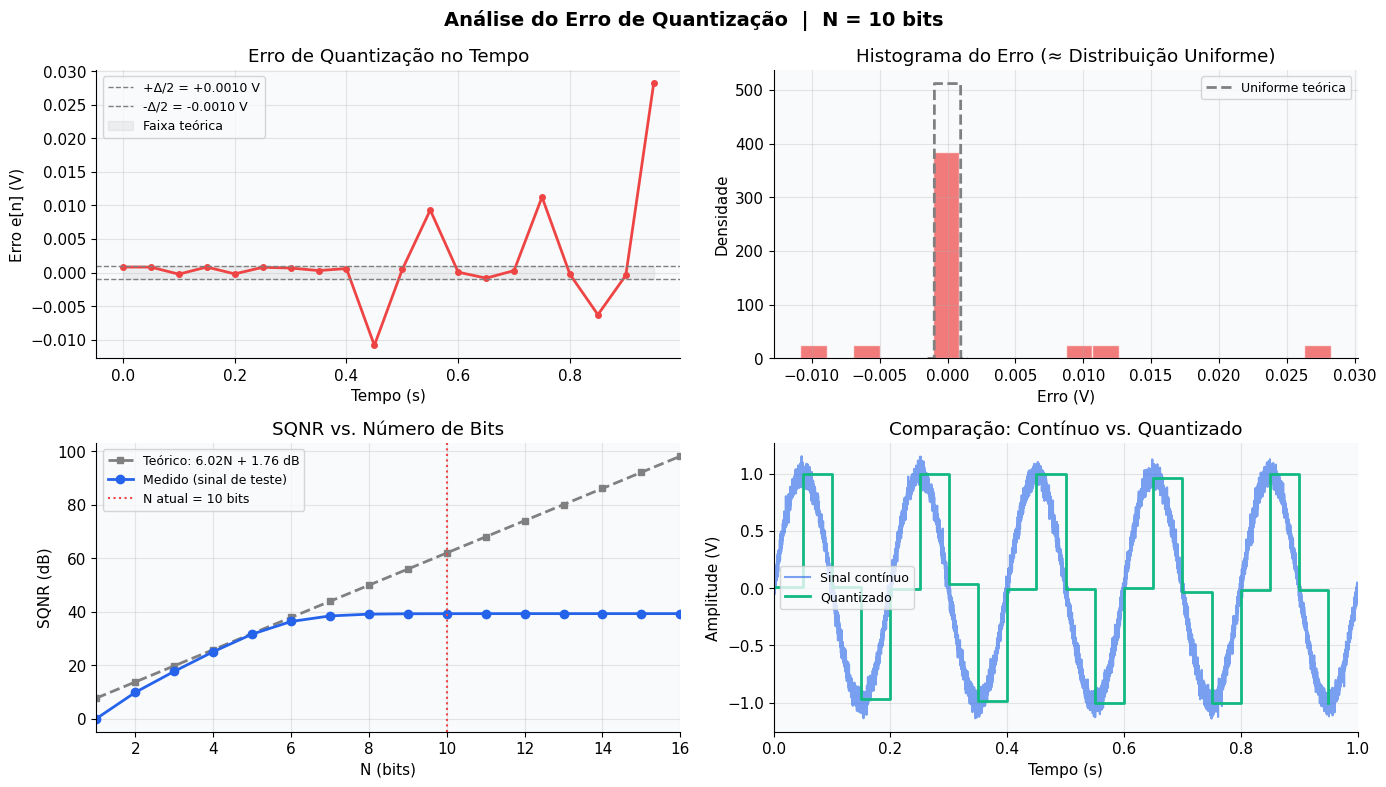

──────────────────────────────────────────────────
  Erro máximo teórico:  ±0.000978 V
  Erro máximo medido:   ±0.028246 V
  SQNR teórico:         61.96 dB
  SQNR medido:          39.29 dB
──────────────────────────────────────────────────


In [11]:
# ── a) Erro de quantização ao longo do tempo ──
erro_q = x_quantizado - x_q_in  # e[n] = x_q[n] - x[n]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(f'Análise do Erro de Quantização  |  N = {n_bits} bits', fontsize=14, fontweight='bold')

# ── Gráfico 1: erro ao longo do tempo ──
ax = axes[0, 0]
ax.plot(t_q, erro_q, color=COR_ERRO, lw=2, marker='o', ms=4)
ax.axhline(delta/2,  color='gray', ls='--', lw=1, label=f'+Δ/2 = +{delta/2:.4f} V')
ax.axhline(-delta/2, color='gray', ls='--', lw=1, label=f'-Δ/2 = -{delta/2:.4f} V')
ax.fill_between(t_q, -delta/2, delta/2, alpha=0.1, color='gray', label='Faixa teórica')
ax.set_title('Erro de Quantização no Tempo')
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Erro e[n] (V)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Gráfico 2: histograma do erro ──
ax = axes[0, 1]
ax.hist(erro_q, bins=20, color=COR_ERRO, alpha=0.7, edgecolor='white', density=True)
# Distribuição uniforme teórica para referência
x_unif = np.linspace(-delta/2*1.5, delta/2*1.5, 200)
y_unif = np.where(np.abs(x_unif) <= delta/2, 1/delta, 0)
ax.plot(x_unif, y_unif, color='gray', lw=2, ls='--', label='Uniforme teórica')
ax.set_title('Histograma do Erro (≈ Distribuição Uniforme)')
ax.set_xlabel('Erro (V)')
ax.set_ylabel('Densidade')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Gráfico 3: SQNR vs N bits ──
ax = axes[1, 0]
bits_range = np.arange(1, 17)
sqnr_teorico = 6.02 * bits_range + 1.76

# Calcula SQNR medido para cada N bits no sinal de teste
sqnr_medido = []
for nb in bits_range:
    x_qt, _, _ = quantizar(x_q_in, nb, v_min, v_max)
    erro = x_qt - x_q_in
    potencia_sinal = np.mean(x_q_in ** 2)
    potencia_erro  = np.mean(erro ** 2)
    # Evita divisão por zero se o erro for nulo (bits muito altos)
    sqnr = 10 * np.log10(potencia_sinal / potencia_erro) if potencia_erro > 0 else 100
    sqnr_medido.append(sqnr)

ax.plot(bits_range, sqnr_teorico, color='gray', ls='--', lw=2, marker='s', ms=5, label='Teórico: 6.02N + 1.76 dB')
ax.plot(bits_range, sqnr_medido, color=COR_ORIGINAL, lw=2, marker='o', ms=6, label='Medido (sinal de teste)')
ax.axvline(n_bits, color=COR_ERRO, ls=':', lw=1.5, label=f'N atual = {n_bits} bits')
ax.set_title('SQNR vs. Número de Bits')
ax.set_xlabel('N (bits)')
ax.set_ylabel('SQNR (dB)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(1, 16)

# ── Gráfico 4: sinal original vs quantizado ──
ax = axes[1, 1]
ax.plot(t_cont, sinal_cont, color=COR_ORIGINAL, lw=1.5, alpha=0.6, label='Sinal contínuo')
ax.step(t_q, x_quantizado, where='post', color=COR_QUANT, lw=2, label='Quantizado')
ax.set_title('Comparação: Contínuo vs. Quantizado')
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Amplitude (V)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, t_total)

plt.tight_layout()
plt.show()

# ── Métricas numéricas ──
potencia_sinal = np.mean(x_q_in**2)
potencia_erro  = np.mean(erro_q**2)
sqnr_teo = 6.02 * n_bits + 1.76
sqnr_med = 10 * np.log10(potencia_sinal / potencia_erro)

print(f'{'─'*50}')
print(f'  Erro máximo teórico:  ±{delta/2:.6f} V')
print(f'  Erro máximo medido:   ±{np.max(np.abs(erro_q)):.6f} V')
print(f'  SQNR teórico:         {sqnr_teo:.2f} dB')
print(f'  SQNR medido:          {sqnr_med:.2f} dB')
print(f'{'─'*50}')

---
## Seção 6 — Pipeline ADC Completo

### O fluxo da conversão

Um conversor analógico-digital (ADC) transforma uma tensão que varia
continuamente em uma sequência de números binários por meio de **etapas
encadeadas**. O diagrama abaixo mostra o caminho completo do sinal — do
sensor até o código binário — e onde termina o "mundo analógico" e começa
o "mundo digital":

```
            MUNDO ANALÓGICO                            MUNDO DIGITAL
────────────────────────────────────────┬────────────────────────────────────────
┌────────────────┐   ┌────────────────┐ ┊ ┌────────────────┐   ┌────────────────┐
│   1. SENSOR    │   │2. SAMPLE & HOLD│ ┊ │ 3. QUANTIZADOR │   │ 4. CODIFICAÇÃO │
│ mede grandeza  │   │congela o valor │ ┊ │ arredonda para │   │  traduz cada   │
│  física real   │──>│amostrado por Ts│──>│1 de 2^N níveis │──>│ nível em bits  │
│                │   │                │ ┊ │                │   │                │
│  saída: x(t)   │   │  x(t) -> x[n]  │ ┊ │ x[n] -> xq[n]  │   │ 0101 1010 ...  │
└────────────────┘   └───────┬────────┘ ┊ └───────┬────────┘   └────────────────┘
                             │          ┊         │
                         clock fs       ┊      N bits
                     (quando amostrar)  ┊ (quantos níveis)
────────────────────────────────────────┴────────────────────────────────────────
```

**Legenda das etapas:**

| Etapa | Bloco | O que faz | Entra → Sai |
|-------|-------|-----------|-------------|
| 1 | **Sensor** | Converte uma grandeza física (som, temperatura, vibração) em tensão elétrica | grandeza física → `x(t)` |
| 2 | **Sample & Hold** | "Congela" o valor da tensão em instantes regulares (a cada `Ts`) e o mantém estável durante a conversão — análogo a tirar uma fotografia | `x(t)` → `x[n]` |
| 3 | **Quantizador** | Arredonda cada amostra para o nível mais próximo entre os `2^N` níveis disponíveis | `x[n]` → `xq[n]` |
| 4 | **Codificação** | Associa cada nível a um código binário de `N` bits | `xq[n]` → `0101…` |

A **linha pontilhada vertical** separa o *mundo analógico* (tensões contínuas)
do *mundo digital* (números inteiros) — a fronteira fica na quantização, pois é
ali que valores contínuos viram níveis discretos. Repare também que dois sinais
de **controle** alimentam o pipeline por baixo: o *clock* `fs` define **quando**
amostrar (Seção 2) e a resolução `N` define **quantos níveis** existem (Seção 4).


 Tempo (s) |  Amostrada (V) |  Quantizada (V) |    Binário
────────────────────────────────────────────────────────────
    0.0000 |       0.009934 |        0.014118 |   10000001
    0.0500 |       0.997235 |        0.992941 |   11101001
    0.1000 |       0.012954 |        0.014118 |   10000001
    0.1500 |      -0.969539 |       -0.974118 |   00011000
    0.2000 |      -0.004683 |       -0.004706 |   01111111
    0.2500 |       0.995317 |        0.992941 |   11101001
    0.3000 |       0.031584 |        0.032941 |   10000011
    0.3500 |      -0.984651 |       -0.983529 |   00010111
    0.4000 |      -0.009389 |       -0.004706 |   01111111
    0.4500 |       1.010851 |        1.011765 |   11101011
    0.5000 |      -0.009268 |       -0.004706 |   01111111
    0.5500 |      -1.009315 |       -1.011765 |   00010100
    0.6000 |       0.004839 |        0.004706 |   10000000
    0.6500 |       0.961734 |        0.964706 |   11100110
    0.7000 |      -0.034498 |       -0.032941 |   0111

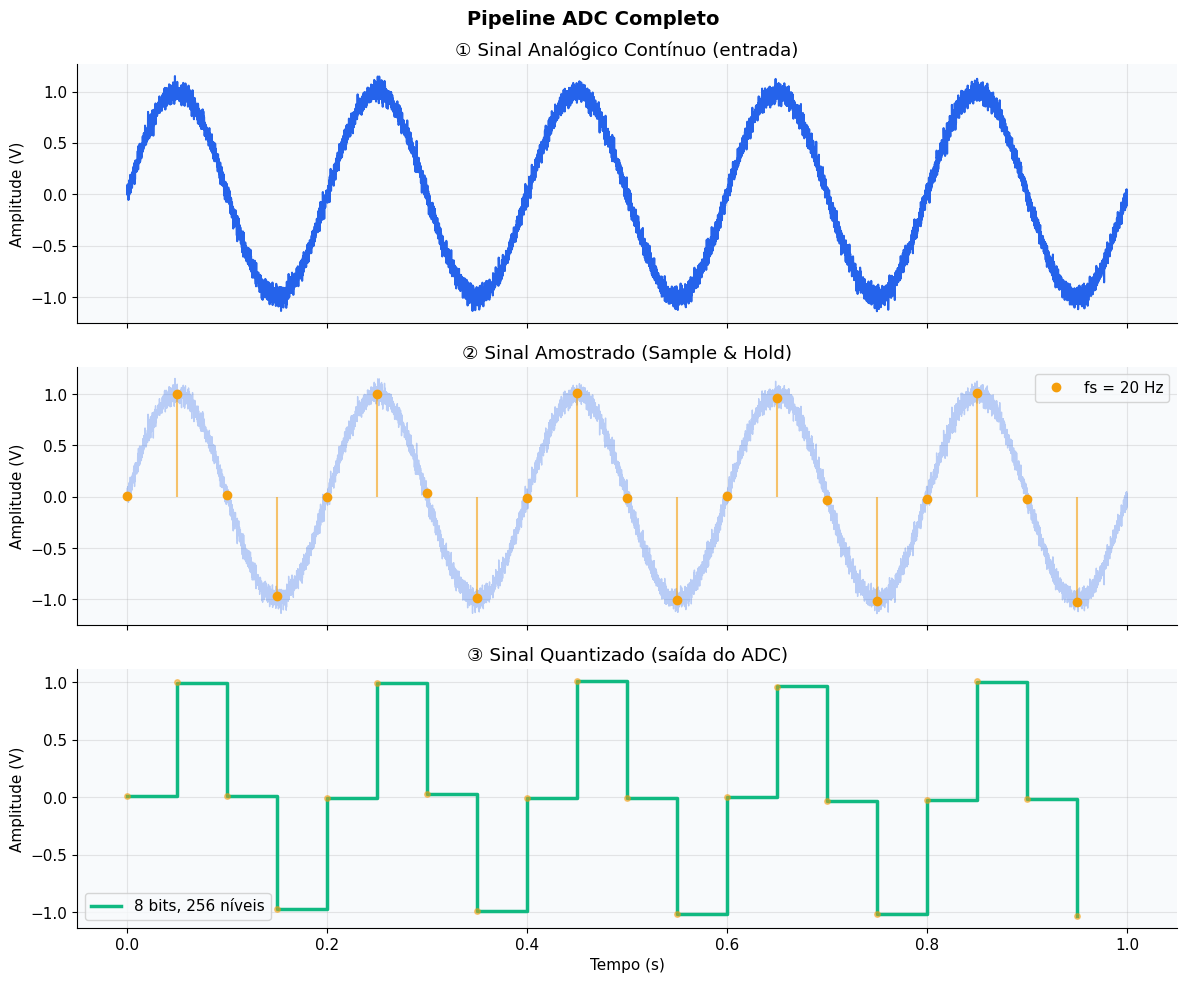

In [14]:
def adc_completo(sinal_func, fs, n_bits, v_min, v_max, t_total=1.0, seed=42):
    """
    Simula o pipeline ADC completo.

    Parâmetros:
        sinal_func : função f(t) → tensão analógica
        fs         : frequência de amostragem (Hz)
        n_bits     : resolução em bits
        v_min/max  : faixa de entrada do ADC (V)
        t_total    : duração do sinal (s)

    Retorna:
        t_am, x_am, x_q, codigos_bin
    """
    np.random.seed(seed)

    # Etapa 1 — Amostragem (Sample & Hold)
    t_am = np.arange(0, t_total, 1/fs)
    x_am = sinal_func(t_am)  # captura valores nos instantes de amostragem

    # Etapa 2 — Quantização
    x_q, delta, n_niveis = quantizar(x_am, n_bits, v_min, v_max)

    # Etapa 3 — Codificação binária
    # Calcula o índice de cada amostra quantizada e converte para binário
    indices = np.round((np.clip(x_q, v_min, v_max) - v_min) / delta).astype(int)
    codigos_bin = [format(idx, f'0{n_bits}b') for idx in indices]

    return t_am, x_am, x_q, codigos_bin, delta


# Define o sinal de teste como função (para passar para adc_completo)
np.random.seed(42)
_ruido_cache = {}
def sinal_teste(t):
    r = np.random.normal(0, noise_std, size=len(t))
    return amplitude * np.sin(2 * np.pi * signal_freq * t) + r

np.random.seed(42)
t_am6, x_am6, x_q6, codigos6, delta6 = adc_completo(
    sinal_func=lambda t: amplitude * np.sin(2*np.pi*signal_freq*t) + np.random.normal(0, noise_std, len(t)),
    fs=20, n_bits=n_bits, v_min=v_min, v_max=v_max
)

# ── Tabela: tempo | tensão amostrada | tensão quantizada | binário ──
print(f"{'Tempo (s)':>10} | {'Amostrada (V)':>14} | {'Quantizada (V)':>15} | {'Binário':>10}")
print('─' * 60)
for i in range(min(15, len(t_am6))):
    print(f"{t_am6[i]:>10.4f} | {x_am6[i]:>14.6f} | {x_q6[i]:>15.6f} | {codigos6[i]:>10}")
if len(t_am6) > 15:
    print(f"  ... ({len(t_am6) - 15} linhas omitidas)")

# ── 3 subplots empilhados ──
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle('Pipeline ADC Completo', fontsize=14, fontweight='bold')

# Subplot 1: sinal contínuo
axes[0].plot(t_cont, sinal_cont, color=COR_ORIGINAL, lw=1.5)
axes[0].set_title('① Sinal Analógico Contínuo (entrada)')
axes[0].set_ylabel('Amplitude (V)')
axes[0].grid(True, alpha=0.3)

# Subplot 2: amostras
axes[1].plot(t_cont, sinal_cont, color=COR_ORIGINAL, lw=1, alpha=0.3)
axes[1].vlines(t_am6, 0, x_am6, color=COR_AMOSTRADO, lw=1.5, alpha=0.6)
axes[1].plot(t_am6, x_am6, 'o', color=COR_AMOSTRADO, ms=6, label=f'fs = 20 Hz')
axes[1].set_title('② Sinal Amostrado (Sample & Hold)')
axes[1].set_ylabel('Amplitude (V)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Subplot 3: sinal quantizado
axes[2].step(t_am6, x_q6, where='post', color=COR_QUANT, lw=2.5, label=f'{n_bits} bits, {2**n_bits} níveis')
axes[2].plot(t_am6, x_am6, 'o', color=COR_AMOSTRADO, ms=4, alpha=0.5)
axes[2].set_title('③ Sinal Quantizado (saída do ADC)')
axes[2].set_ylabel('Amplitude (V)')
axes[2].set_xlabel('Tempo (s)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Seção 7 — Experimento Interativo Consolidado 🔧

> **Instruções:** Altere os parâmetros no bloco marcado abaixo e re-execute a célula (Shift+Enter). Observe como cada mudança afeta os gráficos e as métricas.

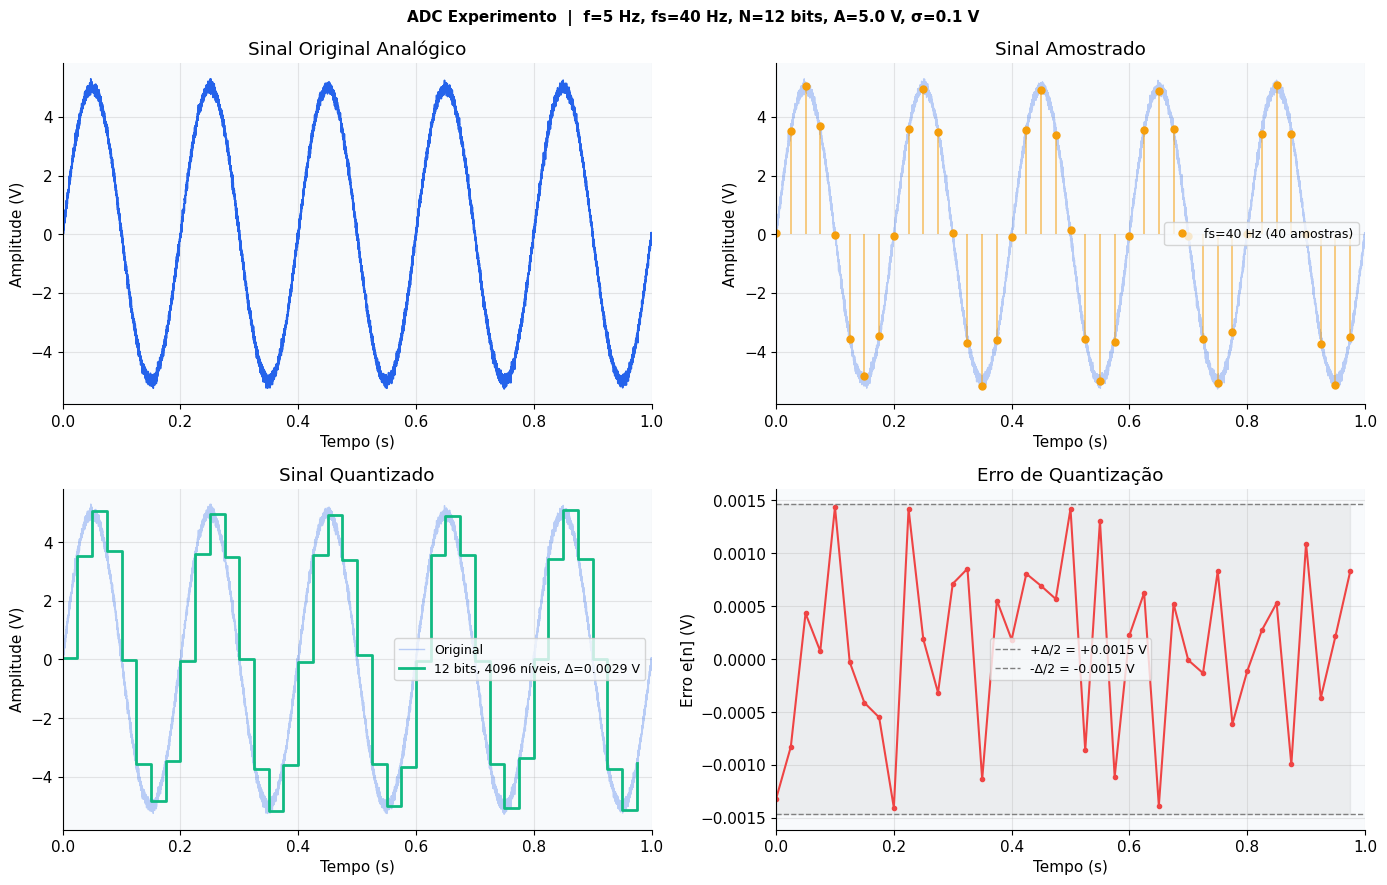


═══════════════════════════════════════════════════════
  MÉTRICAS DO EXPERIMENTO
───────────────────────────────────────────────────────
  Frequência de Nyquist:   20.0 Hz
  Condição de Nyquist:     ✓ OK
  Níveis de quantização:   4096
  Passo (Δ):               0.002930 V
  SQNR teórico:            74.00 dB
  SQNR medido:             72.79 dB
  Erro máx. teórico:       ±0.001465 V
  Erro máx. medido:        ±0.001437 V
═══════════════════════════════════════════════════════


In [19]:
## ===== MUDE ESTES PARÂMETROS E RE-EXECUTE A CÉLULA =====
signal_freq  = 5      # Hz — frequência do sinal analógico
fs           = 40     # Hz — frequência de amostragem
n_bits       = 12     # bits — resolução do ADC
amplitude    = 5.0    # V   — amplitude do sinal
noise_std    = 0.1    # V   — nível de ruído (desvio padrão)
v_min, v_max = -6, 6  # V — faixa de entrada do ADC
## =========================================================

np.random.seed(42)

# Gera sinal contínuo e amostrado
t_exp   = np.linspace(0, 1.0, 10_000, endpoint=False)
sig_exp = amplitude * np.sin(2 * np.pi * signal_freq * t_exp) + \
          np.random.normal(0, noise_std, 10_000)

np.random.seed(42)
t_am_exp = np.arange(0, 1.0, 1/fs)
x_am_exp = amplitude * np.sin(2 * np.pi * signal_freq * t_am_exp) + \
           np.random.normal(0, noise_std, len(t_am_exp))

x_q_exp, delta_exp, n_niv_exp = quantizar(x_am_exp, n_bits, v_min, v_max)
erro_exp = x_q_exp - x_am_exp

# Verifica condição de Nyquist
nyquist_ok = fs >= 2 * signal_freq
aviso = '' if nyquist_ok else f'  ⚠️  ALIASING (fs < 2×{signal_freq} Hz)'

# ── Painel 2×2 ──
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
titulo = (f'ADC Experimento  |  f={signal_freq} Hz, fs={fs} Hz, N={n_bits} bits, '
          f'A={amplitude} V, σ={noise_std} V{aviso}')
fig.suptitle(titulo, fontsize=11, fontweight='bold',
             color='black' if nyquist_ok else '#EF4444')

# [0,0] Sinal original
ax = axes[0, 0]
ax.plot(t_exp, sig_exp, color=COR_ORIGINAL, lw=1.2)
ax.set_title('Sinal Original Analógico')
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Amplitude (V)')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1.0)

# [0,1] Sinal amostrado
ax = axes[0, 1]
ax.plot(t_exp, sig_exp, color=COR_ORIGINAL, lw=1, alpha=0.3)
ax.vlines(t_am_exp, 0, x_am_exp, color=COR_AMOSTRADO, lw=1.2, alpha=0.6)
ax.plot(t_am_exp, x_am_exp, 'o', color=COR_AMOSTRADO, ms=5,
        label=f'fs={fs} Hz ({len(t_am_exp)} amostras)')
ax.set_title('Sinal Amostrado')
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Amplitude (V)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1.0)

# [1,0] Sinal quantizado
ax = axes[1, 0]
ax.plot(t_exp, sig_exp, color=COR_ORIGINAL, lw=1, alpha=0.3, label='Original')
ax.step(t_am_exp, x_q_exp, where='post', color=COR_QUANT, lw=2,
        label=f'{n_bits} bits, {n_niv_exp} níveis, Δ={delta_exp:.4f} V')
ax.set_title('Sinal Quantizado')
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Amplitude (V)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1.0)

# [1,1] Erro de quantização
ax = axes[1, 1]
ax.plot(t_am_exp, erro_exp, color=COR_ERRO, lw=1.5, marker='o', ms=3)
ax.axhline(delta_exp/2,  color='gray', ls='--', lw=1, label=f'+Δ/2 = +{delta_exp/2:.4f} V')
ax.axhline(-delta_exp/2, color='gray', ls='--', lw=1, label=f'-Δ/2 = -{delta_exp/2:.4f} V')
ax.fill_between(t_am_exp, -delta_exp/2, delta_exp/2, alpha=0.1, color='gray')
ax.set_title('Erro de Quantização')
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Erro e[n] (V)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1.0)

plt.tight_layout()
plt.show()

# ── Métricas ──
sqnr_teo_exp = 6.02 * n_bits + 1.76
pot_sig = np.mean(x_am_exp**2)
pot_err = np.mean(erro_exp**2)
sqnr_med_exp = 10 * np.log10(pot_sig / pot_err) if pot_err > 0 else float('inf')

print(f'\n{'═'*55}')
print(f'  MÉTRICAS DO EXPERIMENTO')
print(f'{'─'*55}')
print(f'  Frequência de Nyquist:   {fs/2:.1f} Hz')
print(f'  Condição de Nyquist:     {"✓ OK" if nyquist_ok else "✗ VIOLADA (aliasing)"}')
print(f'  Níveis de quantização:   {n_niv_exp}')
print(f'  Passo (Δ):               {delta_exp:.6f} V')
print(f'  SQNR teórico:            {sqnr_teo_exp:.2f} dB')
print(f'  SQNR medido:             {sqnr_med_exp:.2f} dB')
print(f'  Erro máx. teórico:       ±{delta_exp/2:.6f} V')
print(f'  Erro máx. medido:        ±{np.max(np.abs(erro_exp)):.6f} V')
print(f'{'═'*55}')

---
## Seção 8 — Resumo e Quiz

### Tabela-Resumo dos Conceitos

| Conceito | Definição | Fórmula chave |
|----------|-----------|---------------|
| **Sinal analógico** | Varia continuamente no tempo e em amplitude | $x(t) = A\sin(2\pi f t)$ |
| **Amostragem** | Captura valores em instantes discretos com período $T_s$ | $x[n] = x(nT_s)$ |
| **Frequência de amostragem** | Número de amostras por segundo | $f_s = 1/T_s$ |
| **Teorema de Nyquist** | Condição para reconstrução perfeita | $f_s \geq 2f_{max}$ |
| **Aliasing** | Distorção quando $f_s < 2f_{max}$ | $f_{alias} = \lvert f - kf_s \rvert$ |
| **Quantização** | Arredondamento para níveis discretos | $2^N$ níveis |
| **Passo de quantização** | Distância entre níveis consecutivos | $\Delta = V_{range}/(2^N-1)$ |
| **Erro de quantização** | Diferença entre valor quantizado e real | $e[n] = x_q[n] - x[n]$ |
| **SQNR** | Relação sinal-ruído de quantização | $\approx 6{,}02N + 1{,}76$ dB |

---

## Quiz de Fixação

Responda sem consultar o material. As respostas estão na célula oculta abaixo.

**Questão 1.** Um ADC de 10 bits opera com faixa de ±5 V. Qual é o passo de quantização Δ em mV? Quantos níveis ele possui?

---

**Questão 2.** Um microfone captura áudio com componentes de frequência até 8 kHz. Qual é a frequência de amostragem **mínima** necessária para evitar aliasing? Qual frequência usa o padrão de telefonia (8 kHz)? Há problema?

---

**Questão 3.** Um sinal de 3 Hz é amostrado a 7 Hz. Qual frequência "fantasma" (alias) aparecerá no sinal reconstruído?

---

**Questão 4.** Você tem um ADC de 8 bits. Quanto melhora o SQNR se você trocar por um ADC de 16 bits? Expresse em dB.

---

**Questão 5.** Por que o erro de quantização tem distribuição aproximadamente **uniforme** no intervalo $[-\Delta/2, +\Delta/2]$? O que acontece com esse intervalo quando aumentamos N?

#gabarito

## Gabarito do Quiz

**Q1.** $2^{10} = 1024$ níveis. $\Delta = 10\text{ V} / (1024-1) \approx 9{,}775$ mV.

**Q2.** Mínimo: $f_s \geq 2 \times 8\text{ kHz} = 16$ kHz. O padrão telefônico usa 8 kHz de amostragem para sinais até 4 kHz (filtro anti-aliasing limita a 3,4 kHz). Para áudio até 8 kHz, 8 kHz de amostragem **viola** Nyquist — causaria aliasing.

**Q3.** $f_{alias} = |3 - 7| = 4$ Hz. Mas 4 Hz também excede $f_s/2 = 3{,}5$ Hz, então o alias real é $|4 - 7| = 3$ Hz — o sinal parece idêntico ao original mas está corrompido. *(Cálculo alternativo: $|3 - 1\times 7| = 4$ Hz, que ainda está acima de Nyquist = 3,5 Hz; portanto $|4 - 7| = 3$ Hz = frequência alias final.)*

**Q4.** SQNR melhora em $6{,}02 \times (16-8) = 6{,}02 \times 8 \approx 48{,}2$ dB.

**Q5.** Para um sinal que varia suavemente, a diferença entre o valor real e o nível mais próximo é essencialmente aleatória e igualmente provável em qualquer ponto de $[-\Delta/2, +\Delta/2]$ — daí a distribuição uniforme. Ao aumentar N, $\Delta$ diminui (passo menor), o intervalo do erro encolhe e o ruído de quantização cai — isso é o que o SQNR captura.